<a href="https://colab.research.google.com/github/starsyntaxx/Olist-delivery-prediction/blob/main/notebooks/exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. upload the files

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile
import os

for file_name in uploaded.keys():
    if file_name.endswith(".zip"):
        with zipfile.ZipFile(file_name, 'r') as zip_ref:
            zip_ref.extractall("data")

Import tools.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
os.listdir("data")

['olist_order_payments_dataset.csv',
 'olist_products_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv',
 'product_category_name_translation.csv']

Quick view of the whole daataset.

In [5]:

# Load datasets
orders = pd.read_csv("data/olist_orders_dataset.csv")
customers = pd.read_csv("data/olist_customers_dataset.csv")
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
order_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")

# Store datasets in dictionary
datasets = {
    "orders": orders,
    "customers": customers,
    "geolocation": geolocation,
    "order_reviews": order_reviews,
    "order_items": order_items,
    "order_payments": order_payments,
    "sellers": sellers,
    "products": products
}

# Find maximum number of columns among datasets
max_cols = max(len(df.columns) for df in datasets.values())

# Create schema dictionary
schema_data = {}

for name, df in datasets.items():
    cols = list(df.columns)

    # Pad shorter lists with None
    cols += [None] * (max_cols - len(cols))

    schema_data[name] = cols

# Create schema overview table
schema_table = pd.DataFrame.from_dict(
    schema_data,
    orient='index'
)

# Rename column headers
schema_table.columns = [f"Column_{i+1}" for i in range(max_cols)]

# Display table
schema_table

,Column_1,Column_2,Column_3,Column_4,Column_5,Column_6,Column_7,Column_8,Column_9
orders,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,None
customers,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,None,None,None,None
geolocation,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,None,None,None,None
order_reviews,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,None,None
order_items,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,None,None
order_payments,order_id,payment_sequential,payment_type,payment_installments,payment_value,None,None,None,None
sellers,seller_id,seller_zip_code_prefix,seller_city,seller_state,None,None,None,None,None
products,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


**Workflow 1: Analyze each dataset quality for signals before merging**


**Orders Dataset**

In [6]:
orders = pd.read_csv("data/olist_orders_dataset.csv")
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


QUESTIONS AND NOTE
Exploratory
1. Dataset: A general overview of the data
2. Data Quality: Check for misssing values, outliers, bad data
3. Dataset Relationship: Check relationship between a dataset to another in the whole data frame.
* Order ID - Customer ID - *one-one-relationship*
* Order ID - product ID - *one-one_relationship*
* Order ID - Seller ID
* Order ID - Customer Unique ID

Note: Each exploratory analysis produces complex questions, that will be answered along the way


In [7]:
orders.describe()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


 *Observation; Out of 99441 unque order, only 459 order etimated delivery date were spread out, a number of each had*

 *Hypothesis: A simple algorithm was included, does it stem from location only, was there a correlation*

In [8]:
orders.head()
orders.shape
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [9]:
#Hypothesis: Missing values exist

orders['not_delivered'] = orders['order_delivered_customer_date'].isnull()
orders.groupby('order_status')['not_delivered'].value_counts()

order_status  not_delivered
approved      True                 2
canceled      True               619
              False                6
created       True                 5
delivered     False            96470
              True                 8
invoiced      True               314
processing    True               301
shipped       True              1107
unavailable   True               609
Name: count, dtype: int64

In [10]:
orders['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [11]:
orders[orders['order_status'] == 'shipped']['order_delivered_carrier_date'].isnull().sum()

np.int64(0)

*Missing values observed in delivery timestamp columns were analyzed and found to be primarily associated with the business process state of orders during data capture rather than database inconsistencies or system failures. Orders with statuses such as shipped, processing, or canceled naturally lacked certain downstream delivery timestamps because those events had not yet occurred at the time of recording.*

In [12]:
#Now unto data cleaning
df = orders[orders['order_status'] == 'delivered'].copy()
df['order_delivered_customer_date'].isnull().sum()

#observation: 8 customers with delivered tag are missing delivery dates


np.int64(8)

In [13]:

#question; How many times was the order day predicted wrongly: you can't get the exact time, but at least the day
df['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

df['delivery_delay_days'].head()

,delivery_delay_days
0,-8.0
1,-6.0
2,-18.0
3,-13.0
4,-10.0


On average, orders are delivered approximately 12 days earlier than the estimated delivery date, indicating that the estimation system is conservative. However, there is significant variability in delivery performance, with some extreme early and late deliveries, suggesting inconsistency in logistics or estimation accuracy.

In [14]:
df['delivery_delay_days'].describe()

,delivery_delay_days
count,96470.000000
mean,-11.875889
std,10.182105
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


In [ ]:
df['delivery_delay_days'].value_counts()

,count
delivery_delay_days,
-14.0,7126
-13.0,5963
-15.0,5345
-7.0,4837
-8.0,4828
...,...
-63.0,1
72.0,1
94.0,1


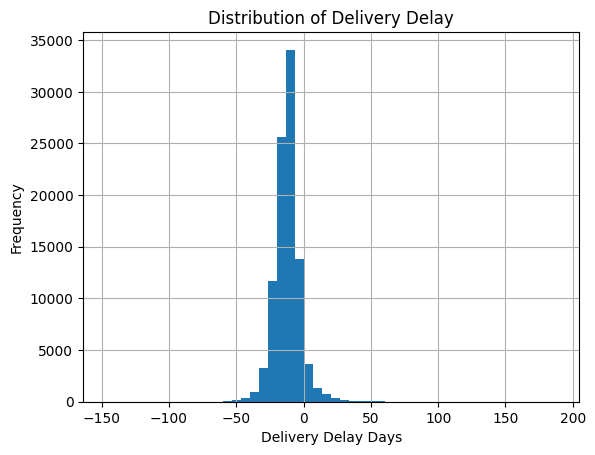

In [15]:

df['delivery_delay_days'].hist(bins=50)

plt.xlabel("Delivery Delay Days")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Delay")

plt.show()

In [16]:
#Was there any order delivery date that was predicted accurately to detect the accuracy of the delivery date?
df['delivery_matched_dates'] = (
    df['order_delivered_customer_date'].dt.date ==
    df['order_estimated_delivery_date'].dt.date
)

df['delivery_matched_dates'].describe()


,delivery_matched_dates
count,96478
unique,2
top,False
freq,95186


In [17]:
matched_orders = df[
    df['order_delivered_customer_date'].dt.date ==
    df['order_estimated_delivery_date'].dt.date
]

matched_orders.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
count,1292,1292,1292,1292.0
mean,2018-02-22 02:03:04.214396160,2018-03-13 07:23:39.443498496,2018-03-12 14:37:09.102167296,0.0
min,2016-10-10 15:01:27,2016-12-14 08:03:48,2016-12-14 00:00:00,0.0
25%,2017-11-25 15:09:24.500000,2017-12-19 15:58:24.500000,2017-12-19 00:00:00,0.0
50%,2018-03-07 09:55:52,2018-03-28 07:17:47,2018-03-28 00:00:00,0.0
75%,2018-07-16 12:12:06.500000,2018-08-01 06:08:30.750000128,2018-08-01 06:00:00,0.0
max,2018-08-28 22:51:54,2018-08-31 02:21:48,2018-08-31 00:00:00,0.0
std,NaN,NaN,NaN,0.0


*Out of 9912 orders and their delivery dates, 1291 orders were accurate as the estimated delivery time equaled the actual delivery date, 95186 were not accurate as the actual delivery dates deviated from the estimated delivery date*

MODEL USAGE
1. Filter out orders without a customer_actual_delivery_time as it is not needed for the model

**Data Frames for Modelling**
Important Filter == Delivered
1. Order Purchase timestamp
2. Order_approved_at
3. Order_estimated_delivery_date
4. Order_status
5. Order_delivered-customer_date


----------------------------------------------------------------Another Dataset--------------------------------------------------------

**Customers Dataset**

In [18]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [19]:
# Check data quality and usability
# treat customer_zip_code_prefix as categorical data type so as To analyze distribution of customers across regions
customers["customer_zip_code_prefix"] = customers["customer_zip_code_prefix"].astype("category")
customers.describe()
#Unique_id is unique to every user, regaardless how many orders are made, it's the same.
# Check the ralationship of city distance with delivery date, if its the same for those with same city distance
#Look aat the yeer with 17 unique orders which correlate with 17 orders, check the relatinship of duration of estimated and actual delivery date with city

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441,99441,99441
unique,99441,96096,14994,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,22790,sao paulo,SP
freq,1,17,142,15540,41746


In [20]:
customers.info()
# relationship question: Number of customers equals order, so the customer correlates with a one-one relationship with the order dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   customer_id               99441 non-null  object  
 1   customer_unique_id        99441 non-null  object  
 2   customer_zip_code_prefix  99441 non-null  category
 3   customer_city             99441 non-null  object  
 4   customer_state            99441 non-null  object  
dtypes: category(1), object(4)
memory usage: 3.8+ MB


In [21]:
customers['customer_unique_id'].value_counts()
#Inference; A number of customers bought products at different times, more than once.

,count
customer_unique_id,
8d50f5eadf50201ccdcedfb9e2ac8455,17
3e43e6105506432c953e165fb2acf44c,9
ca77025e7201e3b30c44b472ff346268,7
1b6c7548a2a1f9037c1fd3ddfed95f33,7
6469f99c1f9dfae7733b25662e7f1782,7
...,...
4f83c83b7ff5b544a8c75dcb8ad66e2e,1
3fe413dde400746c53c5d0d38b266ca2,1
289e1d1ce11a14bb169775d58ad2f1c2,1


Dataset
1. Customer zip code prefix

Advanced: Feature Engineeering behaviour
1. Customers that bought a number of products at once did it affect their delivery time. Order Id from order dataset and Order Id from Order_Product dataset

In [ ]:
# Did all of the customers here engage in orders?
# Observe the relationship between an order estimated time and (i)the review and (ii)number of times it was bought?


----------------------------------------------------------------Another Dataset--------------------------------------------------------

**Geolocation Dataset**;

In [22]:
geolocation = pd.read_csv("data/olist_geolocation_dataset.csv")
geolocation.head(5)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [23]:
geolocation.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0


In [ ]:
geolocation.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


In [ ]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


Dataset:

customer/seller table------> zip_code_prefix-----> geolocation table-latitude-----> longitude

**Order Review Dataset**

In [ ]:
order_reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
order_reviews.head(5)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insightful Questions**

*Does late delivery correlate with low scores?*

*Which sellers get worst reviews?*

*Does delivery time affect satisfaction?*

*The order-review dataset is excluded from model training as it represents post-event information. Including it would introduce target leakage and potentially lead to overfitting, as review scores are influenced by delivery outcomes rather than available at prediction time.*

**Order Items Dataset**

In [ ]:
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [24]:

#order_items['order_item_id'] = order_items['order_item_id'].astype('category')
#order_items['order_item_id'].describe()

#order_items = order_items.astype('category')
order_items.describe()

#Question: The shipping limit date unique total values does not highly correlate with estimated delivery date. A high correlation should exist right?
# Check the relationship between the predicted output and shipping_limit_date	and	freight_value

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [25]:
order_items['order_id'].value_counts()

,count
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15
...,...
5a082b558a3798d3e36d93bfa8ca1eae,1
5a07264682e0b8fbb3f166edbbffc6e8,1
5a071192a28951b76774e5a760c8c9b7,1


orders['order_id'] -> order_items['order_id'] == One-to-many relationship
Orders' counts products, while order_items counts products in orders

Dataset: Filter by order id to have a one-one relationship == 'delivered'
1. Freight_value.
2. Shipping_limit_date.

Advanced: Feature Engineering
1. Does the number of products a customer buy affect delivery date?

**Order Payments Dataset**

In [26]:
order_payments = pd.read_csv("data/olist_order_payments_dataset.csv")
order_payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [ ]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


Dataset:
Advanced: Feature Engineering
1.

**Sellers dataset**

In [27]:
sellers = pd.read_csv("data/olist_sellers_dataset.csv")
sellers.head(5)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Seller-customer: One-to-many relationship.

In [ ]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


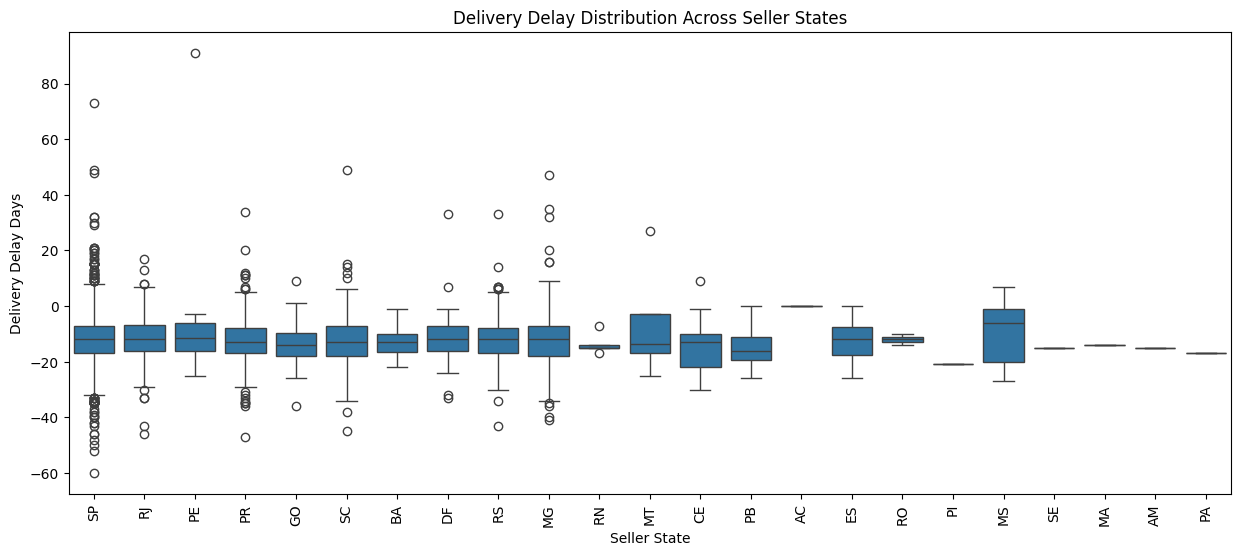

In [ ]:
plt.figure(figsize=(15,6))

sns.boxplot(
    x=sellers['seller_state'],
    y=df['delivery_delay_days'],
    data=df
)

plt.title('Delivery Delay Distribution Across Seller States')

plt.xlabel('Seller State')
plt.ylabel('Delivery Delay Days')

plt.xticks(rotation=90)
plt.show()

*Delivery delay distributions across seller states show that most orders are delivered earlier than the estimated delivery date, suggesting that the platform’s estimation system is generally conservative. While some regional variation exists, seller state alone does not appear to strongly differentiate delivery performance.*

Dataset:
1. Seller_zip_code Prefix: Distance between seller and buyer (new table).
2. Seller_state

Advanced: Feature Engineering.
1. Seller_state importance against bias
2. Seller_id

**Product Dataset**

In [28]:
products = pd.read_csv('data/olist_products_dataset.csv')
products.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


*Interacting with the product dataset.*

In [29]:
products['product_category_name'].value_counts()

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
...,...
fashion_roupa_infanto_juvenil,5
casa_conforto_2,5
pc_gamer,3


In [ ]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
missing_products = products[products['product_category_name'].isnull()]
missing_products_ids = missing_products['product_id']
matched_orders = order_items[order_items['product_id'].isin(missing_products_ids)]

In [ ]:
matched_orders.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
123,0046e1d57f4c07c8c92ab26be8c3dfc0,1,ff6caf9340512b8bf6d2a2a6df032cfa,38e6dada03429a47197d5d584d793b41,2017-10-02 15:49:17,7.79,7.78
125,00482f2670787292280e0a8153d82467,1,a9c404971d1a5b1cbc2e4070e02731fd,702835e4b785b67a084280efca355756,2017-02-17 16:18:07,7.60,10.96
132,004f5d8f238e8908e6864b874eda3391,1,5a848e4ab52fd5445cdc07aab1c40e48,c826c40d7b19f62a09e2d7c5e7295ee2,2018-03-06 09:29:25,122.99,15.61
142,0057199db02d1a5ef41bacbf41f8f63b,1,41eee23c25f7a574dfaf8d5c151dbb12,e5a3438891c0bfdb9394643f95273d8e,2018-01-25 09:07:51,20.30,16.79
171,006cb7cafc99b29548d4f412c7f9f493,1,e10758160da97891c2fdcbc35f0f031d,323ce52b5b81df2cd804b017b7f09aa7,2018-02-22 13:35:28,56.00,14.14


In [ ]:
matched_orders['product_id'].nunique()

610

In [ ]:
missing_products_ids.nunique()

610

*All products with missing product_category_name were still present in actual order transactions, meaning they were successfully sold despite lacking category labels. This indicates that the missing category values are a metadata issue rather than a data availability problem.*

DataSet
1. Product weight
2. Volume = length × height × width
3. Density = weight / volume

**PREPARING DATA FOR MODELLING**

Big Table Merge
order_purchase_timestamp,
order_approved_at,
order_delivered_carrier_date,
order_delivered_customer_date,
delivery_delay_days,
total_fulfillment_time,
processing_time,
shipping_time,
carrier_delay

In [30]:
orders_mutate = orders[orders['order_delivered_carrier_date'].notna()].copy()

In [42]:
orders_completed = orders_mutate.dropna(subset=['order_delivered_customer_date']).copy()

In [44]:
orders_completed.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,not_delivered
count,96475,96475,96475,96475,96461,96475,96475,96475,96475
unique,96475,96475,2,95953,88272,80112,95663,445,1
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2017-11-20 11:46:30,2018-02-27 04:31:10,2018-05-09 15:48:00,2016-10-27 17:32:07,2017-12-20 00:00:00,False
freq,1,1,96469,3,9,47,3,507,96475


In [45]:
order_items_mutated = order_items[order_items['order_id'].isin(orders_completed['order_id'])].copy()

In [47]:
order_items_mutated.describe()

,order_item_id,price,freight_value
count,110195.000000,110195.000000,110195.000000
mean,1.198194,119.975644,19.948576
std,0.706686,182.300655,15.698372
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.900000,16.260000
75%,1.000000,134.170000,21.150000
max,21.000000,6735.000000,409.680000


In [118]:
order_features = order_items_mutated.groupby('order_id').agg({
    'order_item_id': 'max',
    'price': 'sum',
    'freight_value': 'sum',
}).reset_index()

order_features.describe()

,order_item_id,price,freight_value
count,96475.000000,96475.000000,96475.000000
mean,1.142213,137.037741,22.785523
std,0.538818,209.048131,21.559491
min,1.000000,0.850000,0.000000
25%,1.000000,45.900000,13.850000
50%,1.000000,86.500000,17.170000
75%,1.000000,149.900000,24.020000
max,21.000000,13440.000000,1794.960000


In [49]:
products_mutate = products[products['product_id'].isin(order_items_mutated['product_id'])].copy()

In [50]:
products_mutate.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,31629.000000,31629.000000,31629.000000,32211.000000,32211.000000,32211.000000,32211.000000
mean,48.535426,771.517342,2.189699,2269.463972,30.781503,16.871535,23.167148
std,10.214203,634.754197,1.738426,4266.596914,16.861512,13.584723,12.041339
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,974.000000,3.000000,1900.000000,38.000000,20.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [53]:
cols_median = [
    'product_description_lenght',
    'product_name_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in cols_median:
    products_mutate[col] = products_mutate[col].fillna(products_mutate[col].median())


products_mutate['product_category_name'] = products_mutate['product_category_name'].fillna(
    products_mutate['product_category_name'].mode()[0]
)

In [54]:
order_items_full = order_items_mutated.merge(
    products,
    on='product_id',
    how='left'
)

In [56]:
order_features_mutate = order_items_full.groupby('order_id').agg({
    'product_id': 'count',                     # number of products
    'price': 'sum',                            # total spend
    'freight_value': 'sum',                    # total shipping cost
    'product_weight_g': 'sum',                 # total weight
    'product_length_cm': 'mean',               # avg size
    'product_height_cm': 'mean',
    'product_width_cm': 'mean',
    'product_description_lenght': 'mean',
    'product_name_lenght': 'mean',
    'product_photos_qty': 'mean'
}).reset_index()

In [57]:
order_features_mutate.describe()

,product_id,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_description_lenght,product_name_lenght,product_photos_qty
count,96475.000000,96475.000000,96475.000000,96475.000000,96459.000000,96459.000000,96459.000000,95143.000000,95143.000000,95143.000000
mean,1.142213,137.037741,22.785523,2386.348805,30.085165,16.444534,23.010025,793.362613,48.872261,2.250918
std,0.538818,209.048131,21.559491,4769.679923,16.045039,13.240235,11.685070,652.047848,9.940172,1.740365
min,1.000000,0.850000,0.000000,0.000000,7.000000,2.000000,6.000000,4.000000,5.000000,1.000000
25%,1.000000,45.900000,13.850000,300.000000,18.000000,8.000000,15.000000,351.000000,43.000000,1.000000
50%,1.000000,86.500000,17.170000,750.000000,25.000000,13.000000,20.000000,608.000000,52.000000,2.000000
75%,1.000000,149.900000,24.020000,2050.000000,38.000000,20.000000,30.000000,995.000000,57.000000,3.000000
max,21.000000,13440.000000,1794.960000,184400.000000,105.000000,105.000000,118.000000,3992.000000,76.000000,20.000000


In [62]:
order_features_mutated = order_features_mutate.copy()

In [63]:
order_features_mutated[['product_length_cm','product_height_cm','product_width_cm']] = \
order_features_mutated[['product_length_cm','product_height_cm','product_width_cm']].fillna(
    order_features_mutated[['product_length_cm','product_height_cm','product_width_cm']].median()
)

In [64]:
order_features_mutated['product_description_lenght'] = order_features_mutated['product_description_lenght'].fillna(0)
order_features_mutated['product_name_lenght'] = order_features_mutated['product_name_lenght'].fillna(0)
order_features_mutated['product_photos_qty'] = order_features_mutated['product_photos_qty'].fillna(0)

In [65]:
order_features_mutated.describe()

,product_id,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_description_lenght,product_name_lenght,product_photos_qty
count,96475.000000,96475.000000,96475.000000,96475.000000,96475.000000,96475.000000,96475.000000,96475.000000,96475.000000,96475.000000
mean,1.142213,137.037741,22.785523,2386.348805,30.084322,16.443963,23.009526,782.408905,48.197497,2.219840
std,0.538818,209.048131,21.559491,4769.679923,16.043842,13.239211,11.684165,654.115100,11.400223,1.748153
min,1.000000,0.850000,0.000000,0.000000,7.000000,2.000000,6.000000,0.000000,0.000000,0.000000
25%,1.000000,45.900000,13.850000,300.000000,18.000000,8.000000,15.000000,343.000000,42.000000,1.000000
50%,1.000000,86.500000,17.170000,750.000000,25.000000,13.000000,20.000000,600.000000,52.000000,1.500000
75%,1.000000,149.900000,24.020000,2050.000000,38.000000,20.000000,30.000000,988.000000,57.000000,3.000000
max,21.000000,13440.000000,1794.960000,184400.000000,105.000000,105.000000,118.000000,3992.000000,76.000000,20.000000


In [61]:
order_features_mutate.isnull().sum()

,0
order_id,0
product_id,0
price,0
freight_value,0
product_weight_g,0
product_length_cm,16
product_height_cm,16
product_width_cm,16
product_description_lenght,1332
product_name_lenght,1332


In [67]:
date_cols = [
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date'
]

for col in date_cols:
    orders_mutate[col] = pd.to_datetime(orders[col])

In [68]:
orders_mutate['delivery_delay_days'] = (
    orders_mutate['order_delivered_customer_date'] -
    orders_mutate['order_estimated_delivery_date']
).dt.days

In [73]:
orders_mutate['total_fulfillment_time'] = (
    orders_mutate['order_delivered_customer_date'] -
    orders_mutate['order_purchase_timestamp']
).dt.days

In [74]:
orders_mutate['processing_time'] = (
    orders_mutate['order_approved_at'] -
    orders_mutate['order_purchase_timestamp']
).dt.days

In [75]:
orders_mutate['shipping_time'] = (
    orders_mutate['order_delivered_customer_date'] -
    orders_mutate['order_delivered_carrier_date']
).dt.days

In [76]:
orders_mutate['carrier_delay'] = (
    orders_mutate['order_delivered_carrier_date'] -
    orders_mutate['order_approved_at']
).dt.days

In [77]:
#Volume Feature

order_features_mutated['product_volume_cm3'] = (
    order_features_mutated['product_length_cm'] *
    order_features_mutated['product_height_cm'] *
    order_features_mutated['product_width_cm']
)

In [78]:
order_features_mutated['product_volume_cm3'].describe()

,product_volume_cm3
count,96475.000000
mean,15143.480235
std,23227.911053
min,168.000000
25%,2816.000000
50%,6400.000000
75%,18150.000000
max,296208.000000


In [79]:
#Density Feature

order_features_mutated['product_density'] = (
    order_features_mutated['product_weight_g'] / order_features_mutated['product_volume_cm3']
)

order_features_mutated['product_density'] = order_features_mutated['product_density'].replace(
    [float('inf'), -float('inf')],
    0
)

In [80]:
# Max-Dimension Feature

order_features_mutated['max_dimension_cm'] = order_features_mutated[
    ['product_length_cm', 'product_height_cm', 'product_width_cm']
].max(axis=1)

In [82]:
# Bulkiness Score

order_features_mutated['bulkiness_score'] = (
    order_features_mutated['product_volume_cm3'] *
    order_features_mutated['max_dimension_cm']
)

Ultimate filter for data modelling
Orders['order_id'] == 'delivered' and filter all values from different dataset

In [83]:
# Number of unique products
unique_products =  order_features_mutated.groupby('order_id')['product_id'].nunique().reset_index(name='unique_products_count')

In [84]:
# Number of unique categories
#unique_categories = order_items.groupby('order_id')['product_category_name'].nunique().reset_index(name='unique_category_count')

In [85]:
# Averaga Item Price
#avg_price = order_items.groupby('order_id')['price'].mean().reset_index(name='avg_item_price')

In [86]:
# Price Variability
#price_std = order_items.groupby('order_id')['price'].std().reset_index(name='price_std')
#price_std['price_std'] = price_std['price_std'].fillna(0)

In [87]:
# Compute Logistics Distance

import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

In [99]:
customers_mutate = customers.copy()
sellers_mutate = sellers.copy()

In [113]:
customers_filtered = customers_mutate[
    customers_mutate['customer_id'].isin(orders_completed['customer_id'])
].copy()

In [114]:
customers_filtered.describe()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,96475,96475,96475,96475,96475
unique,96475,93355,14889,4085,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,22790,sao paulo,SP
freq,1,15,136,15046,40494


In [121]:
geolocation_mutate = geolocation.copy()

In [122]:
# clean geolocation table
geo_grouped = geolocation_mutate.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

In [123]:
# Rename columns: Immportant for merging
geo_grouped.columns = [
    'zip_code_prefix',
    'lat',
    'lng'
]

In [126]:
geolocation_mutated = geo_grouped[
    geo_grouped['zip_code_prefix'].isin(customers_filtered['customer_zip_code_prefix'])
].copy()

In [127]:
geolocation_mutated.describe()

,zip_code_prefix,lat,lng
count,14737.000000,14737.000000,14737.000000
mean,40200.087399,-19.807366,-46.122821
std,31365.057632,6.861880,4.854855
min,1003.000000,-33.689948,-72.668881
25%,9570.000000,-23.582952,-48.821504
50%,35040.000000,-22.811456,-46.640060
75%,69908.000000,-16.436386,-43.433393
max,99980.000000,42.184003,-8.723762


In [144]:
# Merge Customer Location
customers_geo = customers_filtered.merge(
    geo_grouped,
    left_on='customer_zip_code_prefix',
    right_on='zip_code_prefix',
    how='left'
)

customers_geo = customers_geo.rename(columns={
    'lat': 'customer_lat',
    'lng': 'customer_lng'
})

In [145]:
customers_geo.describe()

,customer_zip_code_prefix,zip_code_prefix,customer_lat,customer_lng
count,96475.000000,96211.000000,96211.000000,96211.000000
mean,35199.193034,35120.945432,-21.201891,-46.188656
std,29839.677234,29826.107470,5.600056,4.054167
min,1003.000000,1003.000000,-33.689948,-72.668881
25%,11355.000000,11320.000000,-23.589855,-48.118347
50%,24436.000000,24360.000000,-22.924970,-46.631931
75%,59056.000000,58697.500000,-20.140216,-43.624911
max,99980.000000,99980.000000,42.184003,-8.723762


In [134]:
# Fill latitude
customers_geo['customer_lat'] = customers_geo.groupby(
    'customer_zip_code_prefix'
)['customer_lat'].transform(lambda x: x.fillna(x.mean()))

# Fill longitude
customers_geo['customer_lng'] = customers_geo.groupby(
    'customer_zip_code_prefix'
)['customer_lng'].transform(lambda x: x.fillna(x.mean()))

# Fill zip (categorical) properly
customers_geo['customer_zip_code_prefix'] = customers_geo['customer_zip_code_prefix'].fillna(
    customers_geo['customer_zip_code_prefix'].mode()[0]
)

In [142]:
sellers_filtered = sellers_mutate[
    sellers_mutate['seller_id'].isin(order_items_mutated['seller_id'])
].copy()

In [143]:

# Merge sellers location

sellers_geo = sellers_mutate.merge(
    geo_grouped,
    left_on='seller_zip_code_prefix',
    right_on='zip_code_prefix',
    how='left'
)

sellers_geo = sellers_geo.rename(columns={
    'lat': 'seller_lat',
    'lng': 'seller_lng'
})

In [146]:
sellers_geo.describe()

,seller_zip_code_prefix,zip_code_prefix,seller_lat,seller_lng
count,3095.000000,3088.000000,3088.000000,3088.000000
mean,32291.059451,32245.904145,-23.045623,-47.362708
std,32713.453830,32697.325786,3.175693,2.805850
min,1001.000000,1001.000000,-32.079231,-67.813284
25%,7093.500000,7092.500000,-23.649078,-49.071480
50%,14940.000000,14940.000000,-23.489724,-46.792049
75%,64552.500000,63150.000000,-22.273913,-46.525299
max,99730.000000,99730.000000,-2.501242,-34.855616


In [ ]:
orders['distance_km'] = haversine(
    orders['customer_lat'],
    orders['customer_lng'],
    orders['seller_lat'],
    orders['seller_lng']
)